In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, confusion_matrix, roc_auc_score, make_scorer, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, ParameterGrid
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.utils import resample
from ctgan.synthesizers.ctgan import CTGAN
import xgboost as xgb

In [2]:
fig_save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\figures\CTGAN"
os.makedirs(fig_save_dir, exist_ok=True)

In [3]:
# Load the Excel file
file_path =  r"D:\Singapore\Alzheimer\R files\final data_new\Variable list-11MAY2025.xlsx"
df_Variables = pd.read_excel(file_path)

In [4]:
file_path_1 = r"D:\Singapore\Alzheimer\R files\final data_new\imoutations_diff_ks\final_data_imputed_k1.csv"
df_Data = pd.read_csv(file_path_1)
df_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677 entries, 0 to 676
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RID                    677 non-null    int64  
 1   AGE                    677 non-null    int64  
 2   PTGENDER               677 non-null    int64  
 3   PTEDUCAT               677 non-null    int64  
 4   PTRACCAT               677 non-null    int64  
 5   PTMARRY                677 non-null    int64  
 6   APOE4                  677 non-null    int64  
 7   FDG                    677 non-null    float64
 8   AV45                   677 non-null    float64
 9   ABETA                  677 non-null    float64
 10  TAU                    677 non-null    float64
 11  PTAU                   677 non-null    float64
 12  CDRSB                  677 non-null    float64
 13  ADAS11                 677 non-null    float64
 14  ADAS13                 677 non-null    float64
 15  ADASQ4

In [5]:
# Group features based on the "Group" column
demographics = df_Variables[df_Variables['Group'] == 'Demographic']['Predictor'].tolist()
clinical_cognitive = df_Variables[df_Variables['Group'] == 'Clinical/Cognitive']['Predictor'].tolist()
biomarker = df_Variables[df_Variables['Group'] == 'Biomarker']['Predictor'].tolist()
neuroimaging = df_Variables[df_Variables['Group'] == 'Neuroimaging']['Predictor'].tolist()

# Optional: Print or check lists
print("Demographics:", demographics)
print("Clinical/Cognitive:", clinical_cognitive)
print("Biomarker:", biomarker)
print("Neuroimaging:", neuroimaging)

Demographics: ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY']
Clinical/Cognitive: ['CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
Biomarker: ['FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
Neuroimaging: ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']


In [6]:
# Group combinations
group_1 = demographics + clinical_cognitive
group_2 = demographics + biomarker
group_3 = demographics + clinical_cognitive + biomarker
group_4 = neuroimaging

In [7]:
print(f'group_1:\n', group_1)
print('*'*100)
print(f'group_2:\n', group_2)
print('*'*100)
print(f'group_3:\n', group_3)
print('*'*100)
print(f'group_4:\n', group_4)

group_1:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
****************************************************************************************************
group_2:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
****************************************************************************************************
group_3:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl', 'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
****************************************************************************************************
group_4:
 ['Ventricles', 'Hippocampus', 'Who

In [8]:
# CTGAN + RF and CTGAN + XGBoost for group_2

def compute_confidence_interval(metric_fn, y_true, y_score, threshold=None, n_bootstraps=1000, ci=0.95):
    stats = []
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    rng = np.random.RandomState(100)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue

        if threshold is not None:
            y_pred = (y_score[indices] >= threshold).astype(int)
            value = metric_fn(y_true[indices], y_pred)
        else:
            value = metric_fn(y_true[indices], y_score[indices])

        stats.append(value)

    lower = np.percentile(stats, (1 - ci) / 2 * 100)
    upper = np.percentile(stats, (1 + ci) / 2 * 100)
    return lower, upper

def generate_synthetic_and_run_model(group_columns, df, group_name,
                                     target_col="convert_Within_3Years",
                                     method="RF",  # "RF" or "XGBoost"
                                     test_size=0.3,
                                     random_state=100,
                                     sample_multiplier=[1, 2, 3]):
    # Only allow group_2
    if group_name not in ["group_2"]:
        raise ValueError(f"CTGAN augmentation is only supported for 'group_2'. Got: {group_name}")

    real_data_group = pd.concat([df[group_columns], df[target_col]], axis=1)

    train_data, test_data = train_test_split(
        real_data_group,
        test_size=test_size,
        random_state=random_state,
        stratify=real_data_group[target_col]
    )
    
    
    np.random.seed(42)
    torch.manual_seed(42)

    
    print(f"Using CTGAN for {group_name}")


    synthesizer = CTGAN(
        embedding_dim=64,
        generator_dim=[128, 128],
        discriminator_dim=[128, 128],
        batch_size=64,
        epochs=50,
        pac=1,
        cuda=True,
        verbose=True
    )
    
    synthesizer.fit(train_data)

    results = []

    for mult in sample_multiplier:
        synthetic_data = synthesizer.sample(len(train_data) * mult)
        save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\CTGAN\group_2"        
        filename = f"synthetic_{group_name}_CTGAN_{mult}x.csv"
        save_path = os.path.join(save_dir, filename)
        synthetic_data.to_csv(save_path, index=False)

        augmented_train = pd.concat([train_data, synthetic_data], ignore_index=True)
        
        X_train_aug = augmented_train[group_columns]
        y_train_aug = augmented_train[target_col]
        X_test = test_data[group_columns]
        y_test = test_data[target_col]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

        if method.upper() == "RF":
            model = RandomForestClassifier(random_state=100, class_weight='balanced')
            param_dist = {
                'n_estimators': [150, 200],
                'max_depth': [2, 3],
                'min_samples_split': [10, 15],
                'min_samples_leaf': [6, 8, 10],
                'max_features': ['log2'],
                'bootstrap': [True],
                'max_samples': [0.5, 0.7, 0.9]
            }
        elif method.upper() == "XGBOOST":
            neg_count = (y_train_aug == 0).sum()
            pos_count = (y_train_aug == 1).sum()
            scale_pos_weight = neg_count / pos_count
            model = xgb.XGBClassifier(eval_metric='logloss', random_state=100, scale_pos_weight=scale_pos_weight)
            param_dist = {
                'n_estimators': [50, 100],
                'max_depth': [2, 3],
                'learning_rate': [0.005],
                'subsample': [0.6, 0.7],
                'colsample_bytree': [0.5, 0.7],
                'gamma': [2, 5],
                'reg_alpha': [5, 10],
                'reg_lambda': [3.0, 5.0]
            }
        else:
            raise ValueError(f"Invalid method '{method}'. Choose 'RF' or 'XGBoost'.")

        def specificity_score(y_true, y_pred):
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            return tn / (tn + fp) if (tn + fp) > 0 else 0

        scoring = {
            'roc_auc': 'roc_auc',
            'f1': make_scorer(f1_score),
            'recall': make_scorer(recall_score),
            'specificity': make_scorer(specificity_score)
        }
        search = RandomizedSearchCV(
            model,
            param_distributions=param_dist,
            cv=cv,
            scoring=scoring,
            refit='roc_auc',
            random_state=100
        )

        search.fit(X_train_aug, y_train_aug)
        best_params = search.best_params_

        # Calibration step
        uncalibrated_model = xgb.XGBClassifier(**best_params, random_state=100, scale_pos_weight=scale_pos_weight) if method.upper() == "XGBOOST" else RandomForestClassifier(**best_params, random_state=100, class_weight='balanced')
        calibrated_model = CalibratedClassifierCV(uncalibrated_model, method='isotonic', cv=3)
        calibrated_model.fit(X_train_aug, y_train_aug)

        y_train_proba = calibrated_model.predict_proba(X_train_aug)[:, 1]
        y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

        # --- Youden threshold ---
        youden_thresholds = []
        for train_idx, val_idx in cv.split(X_train_aug, y_train_aug):
          X_tr, X_val = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
          y_tr, y_val = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

          if method.upper() == "XGBOOST":
            model_cv = xgb.XGBClassifier(**best_params, random_state=100, scale_pos_weight=scale_pos_weight)
          else:
            model_cv = RandomForestClassifier(**best_params, random_state=100, class_weight='balanced')
          model_cv_calibrated = CalibratedClassifierCV(model_cv, method='isotonic', cv=3)
          model_cv_calibrated.fit(X_tr, y_tr)

          y_val_proba = model_cv_calibrated.predict_proba(X_val)[:, 1]
          fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
          youden = tpr - fpr
          best_thresh = thresholds[np.argmax(youden)]
          youden_thresholds.append(best_thresh)

        optimal_threshold = np.mean(youden_thresholds)

        y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
        y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

        # Evaluation metrics
        test_f1 = f1_score(y_test, y_test_pred)
        test_recall = recall_score(y_test, y_test_pred)
        tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
        test_specificity = tn_test / (tn_test + fp_test)
        test_auc = roc_auc_score(y_test, y_test_proba)

        train_f1 = f1_score(y_train_aug, y_train_pred)
        train_recall = recall_score(y_train_aug, y_train_pred)
        tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train_aug, y_train_pred).ravel()
        train_specificity = tn_train / (tn_train + fp_train)
        train_auc = roc_auc_score(y_train_aug, y_train_proba)

        cv_results = search.cv_results_
        best_idx = search.best_index_
        cv_auc = cv_results['mean_test_roc_auc'][best_idx]
        cv_f1 = cv_results['mean_test_f1'][best_idx]
        cv_recall = cv_results['mean_test_recall'][best_idx]
        cv_specificity = cv_results['mean_test_specificity'][best_idx]

        ci_auc = compute_confidence_interval(roc_auc_score, y_test, y_test_proba, threshold=None)
        ci_f1 = compute_confidence_interval(f1_score, y_test, y_test_proba, threshold=optimal_threshold)
        ci_recall = compute_confidence_interval(recall_score, y_test, y_test_proba, threshold=optimal_threshold)
        ci_spec = compute_confidence_interval(specificity_score, y_test, y_test_proba, threshold=optimal_threshold)

        n_bins = 10
        n_bootstrap = 1000
        ci = 99
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
        bootstrap_curves = []
        rng = np.random.RandomState(100)
        
        for _ in range(n_bootstrap):
            indices = rng.randint(0, len(y_test), len(y_test))
            y_bs = y_test.iloc[indices]
            p_bs = y_test_proba[indices]
            if len(np.unique(y_bs)) < 2:
                continue
            for _ in range(n_bootstrap):
                y_bs, p_bs = resample(y_test, y_test_proba, random_state=None)
            try:
                pt_bs, pp_bs = calibration_curve(y_bs, p_bs, n_bins=n_bins, strategy='uniform')
                interp = np.interp(bin_centers, pp_bs, pt_bs)
                bootstrap_curves.append(interp)
            except:
                continue

        bootstrap_array = np.array(bootstrap_curves)
        lower_bound = np.percentile(bootstrap_array, (100 - ci) / 2, axis=0)
        upper_bound = np.percentile(bootstrap_array, 100 - (100 - ci) / 2, axis=0)

        prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=n_bins, strategy='uniform')
        plt.figure(figsize=(6, 6))
        plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
        plt.fill_between(bin_centers, lower_bound, upper_bound, color='blue', alpha=0.2, label='99% CI')
        plt.xlabel('Predicted Probability')
        plt.ylabel('True Probability')
        plt.title(f'Calibration Plot (Test Set) for {group_name}, {method}, Multiplier {mult}')
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.savefig(os.path.join(fig_save_dir, f"calibration_{group_name}_{method}_Multiplier_{mult}.pdf"), dpi=600,bbox_inches="tight")
        plt.show()
        plt.close()


        results.append({
            'group': group_name,
            'method': method,
            'sample_multiplier': mult,
            'train_auc': train_auc,
            'cv_auc': cv_auc,
            'test_auc': test_auc,
            'train_f1': train_f1,
            'cv_f1': cv_f1,
            'test_f1': test_f1,
            'train_recall': train_recall,
            'cv_recall': cv_recall,
            'test_recall': test_recall,
            'train_specificity': train_specificity,
            'cv_specificity': cv_specificity,
            'test_specificity': test_specificity,
            'ci_auc': ci_auc,
            'ci_f1': ci_f1,
            'ci_recall': ci_recall,
            'ci_specificity': ci_spec,
            'best_params': search.best_params_
        })

    return results


Using CTGAN for group_2


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-00.35) | Discrim. (-00.42): 100%|███████████████████████████████████████████████| 50/50 [00:12<00:00,  4.00it/s]


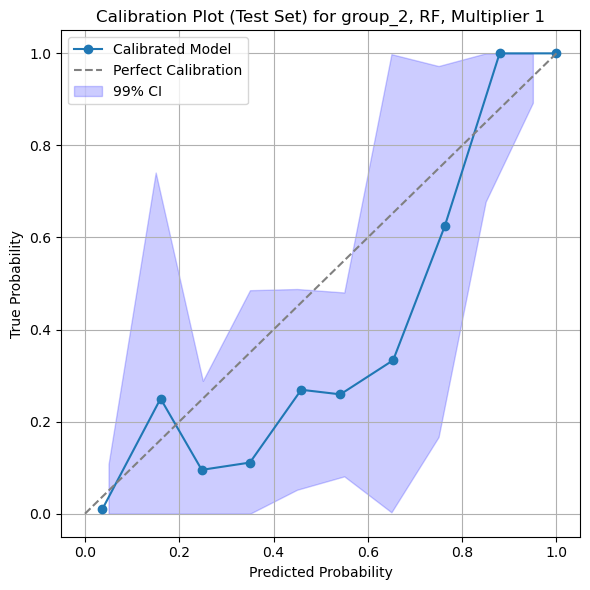

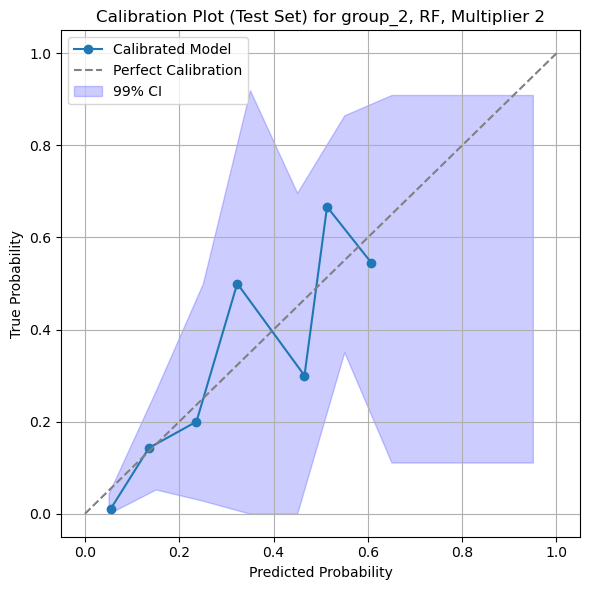

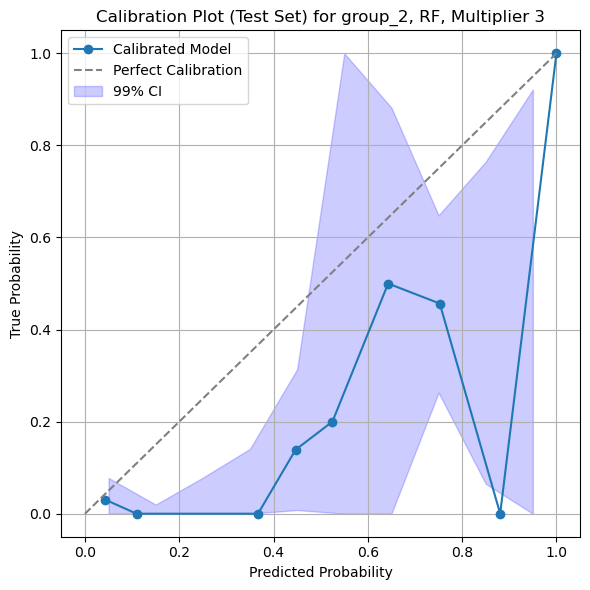

Using CTGAN for group_2


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-00.35) | Discrim. (-00.42): 100%|███████████████████████████████████████████████| 50/50 [00:12<00:00,  4.05it/s]


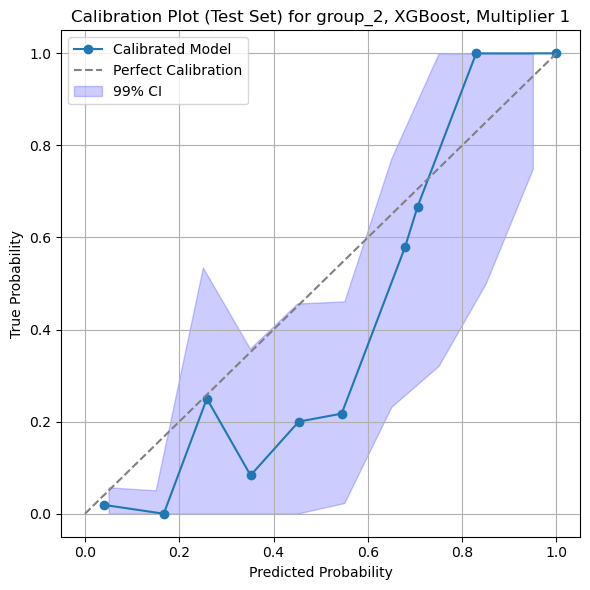

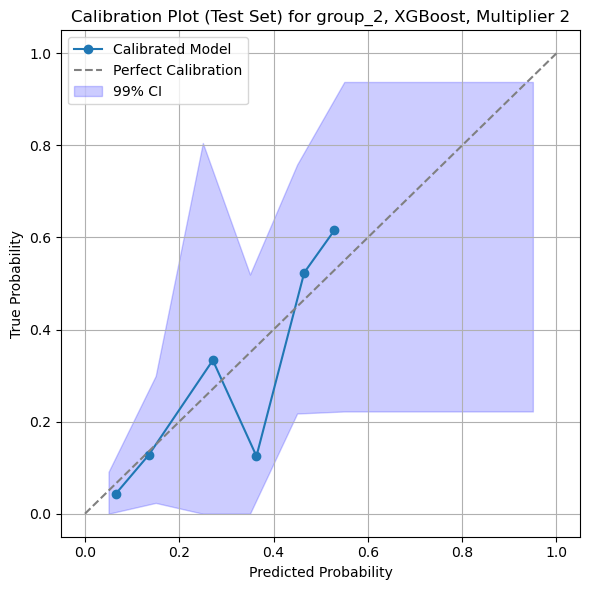

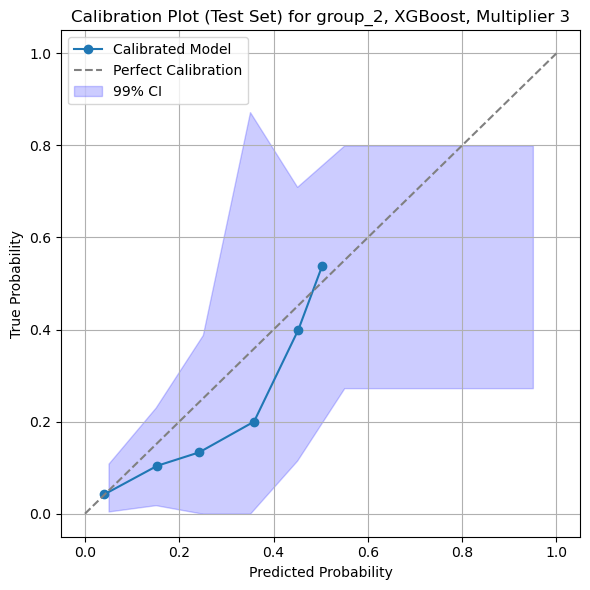

In [9]:
results_rf_group_2 = generate_synthetic_and_run_model(
    group_columns=group_2,
    df=df_Data,
    group_name="group_2",
    method="RF"
)

results_xgb_group_2 = generate_synthetic_and_run_model(
    group_columns=group_2,
    df=df_Data,
    group_name="group_2",
    method="XGBoost"
)

In [10]:
all_results = [results_rf_group_2, results_xgb_group_2]

In [11]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train AUC": round(res["train_auc"], 3),
            "CV AUC": round(res["cv_auc"], 3),
            "Test AUC": round(res["test_auc"], 3),
            "AUC CI Lower": round(res["ci_auc"][0], 3),
            "AUC CI Upper": round(res["ci_auc"][1], 3)
        })

# Convert to DataFrame and display
summary_df_group_2_auc = pd.DataFrame(summary_data)
print(summary_df_group_2_auc.to_markdown(index=False))


| Group   | Method   |   Multiplier |   Train AUC |   CV AUC |   Test AUC |   AUC CI Lower |   AUC CI Upper |
|:--------|:---------|-------------:|------------:|---------:|-----------:|---------------:|---------------:|
| group_2 | RF       |            1 |       0.889 |    0.789 |      0.869 |          0.803 |          0.927 |
| group_2 | RF       |            2 |       0.828 |    0.728 |      0.871 |          0.803 |          0.927 |
| group_2 | RF       |            3 |       0.826 |    0.681 |      0.849 |          0.777 |          0.911 |
| group_2 | XGBoost  |            1 |       0.884 |    0.798 |      0.861 |          0.79  |          0.927 |
| group_2 | XGBoost  |            2 |       0.838 |    0.721 |      0.859 |          0.786 |          0.924 |
| group_2 | XGBoost  |            3 |       0.778 |    0.685 |      0.831 |          0.751 |          0.9   |


In [12]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],


            "Train Recall": round(res["train_recall"], 3),
            "CV Recall": round(res["cv_recall"], 3),
            "Test Recall": round(res["test_recall"], 3),
            "Recall CI Lower": round(res["ci_recall"][0], 3),
            "Recall CI Upper": round(res["ci_recall"][1], 3)
        })

# Convert to DataFrame and display
summary_df_group_2_recall = pd.DataFrame(summary_data)
print(summary_df_group_2_recall.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train Recall |   CV Recall |   Test Recall |   Recall CI Lower |   Recall CI Upper |
|:--------|:---------|-------------:|---------------:|------------:|--------------:|------------------:|------------------:|
| group_2 | RF       |            1 |          0.71  |       0.6   |         0.906 |             0.793 |             1     |
| group_2 | RF       |            2 |          0.527 |       0.534 |         0.875 |             0.75  |             0.972 |
| group_2 | RF       |            3 |          0.45  |       0.406 |         0.906 |             0.793 |             1     |
| group_2 | XGBoost  |            1 |          0.68  |       0.64  |         0.844 |             0.707 |             0.96  |
| group_2 | XGBoost  |            2 |          0.519 |       0.519 |         0.812 |             0.667 |             0.939 |
| group_2 | XGBoost  |            3 |          0.356 |       0.425 |         0.656 |             0.476 |             0.833 |


In [13]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train Specificity": round(res["train_specificity"], 3),
            "CV Specificity": round(res["cv_specificity"], 3),
            "Test Specificity": round(res["test_specificity"], 3),
            "Specificity CI Lower": round(res["ci_specificity"][0], 3),
            "Specificity CI Upper": round(res["ci_specificity"][1], 3)
        })

# Convert to DataFrame and display
summary_df_group_2_spec = pd.DataFrame(summary_data)
print(summary_df_group_2_spec.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train Specificity |   CV Specificity |   Test Specificity |   Specificity CI Lower |   Specificity CI Upper |
|:--------|:---------|-------------:|--------------------:|-----------------:|-------------------:|-----------------------:|-----------------------:|
| group_2 | RF       |            1 |               0.861 |            0.89  |              0.634 |                  0.563 |                  0.703 |
| group_2 | RF       |            2 |               0.932 |            0.902 |              0.779 |                  0.718 |                  0.841 |
| group_2 | RF       |            3 |               0.928 |            0.925 |              0.616 |                  0.549 |                  0.687 |
| group_2 | XGBoost  |            1 |               0.878 |            0.877 |              0.703 |                  0.639 |                  0.769 |
| group_2 | XGBoost  |            2 |               0.924 |            0.898 |              0.773 | 

In [14]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train F1": round(res["train_f1"], 3),
            "CV F1": round(res["cv_f1"], 3),
            "Test F1": round(res["test_f1"], 3),
            "F1 CI Lower": round(res["ci_f1"][0], 3),
            "F1 CI Upper": round(res["ci_f1"][1], 3),
        })

# Convert to DataFrame and display
summary_df_group_2_f1 = pd.DataFrame(summary_data)
print(summary_df_group_2_f1.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train F1 |   CV F1 |   Test F1 |   F1 CI Lower |   F1 CI Upper |
|:--------|:---------|-------------:|-----------:|--------:|----------:|--------------:|--------------:|
| group_2 | RF       |            1 |      0.491 |   0.475 |     0.468 |         0.349 |         0.576 |
| group_2 | RF       |            2 |      0.479 |   0.425 |     0.571 |         0.447 |         0.679 |
| group_2 | RF       |            3 |      0.403 |   0.367 |     0.457 |         0.342 |         0.563 |
| group_2 | XGBoost  |            1 |      0.502 |   0.476 |     0.491 |         0.371 |         0.598 |
| group_2 | XGBoost  |            2 |      0.458 |   0.406 |     0.536 |         0.406 |         0.66  |
| group_2 | XGBoost  |            3 |      0.412 |   0.305 |     0.538 |         0.385 |         0.674 |


In [15]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],
            "Best Params": str(res["best_params"])
        })

# Convert to DataFrame and display
summary_df_group_2_bestparams = pd.DataFrame(summary_data)
print(summary_df_group_2_bestparams.to_markdown(index=False))

| Group   | Method   |   Multiplier | Best Params                                                                                                                                              |
|:--------|:---------|-------------:|:---------------------------------------------------------------------------------------------------------------------------------------------------------|
| group_2 | RF       |            1 | {'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_samples': 0.7, 'max_features': 'log2', 'max_depth': 3, 'bootstrap': True}     |
| group_2 | RF       |            2 | {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_samples': 0.9, 'max_features': 'log2', 'max_depth': 3, 'bootstrap': True}     |
| group_2 | RF       |            3 | {'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_samples': 0.7, 'max_features': 'log2', 'max_depth': 3, 'bootstrap': True}     |
| group_2 | XGBoost  |            1

In [16]:
# CTGAN + RF and CTGAN + XGBoost for group_1 and group_3

def compute_confidence_interval(metric_fn, y_true, y_score, threshold=None, n_bootstraps=1000, ci=0.95):
    stats = []
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    rng = np.random.RandomState(100)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue

        if threshold is not None:
            y_pred = (y_score[indices] >= threshold).astype(int)
            value = metric_fn(y_true[indices], y_pred)
        else:
            value = metric_fn(y_true[indices], y_score[indices])

        stats.append(value)

    lower = np.percentile(stats, (1 - ci) / 2 * 100)
    upper = np.percentile(stats, (1 + ci) / 2 * 100)
    return lower, upper

def generate_synthetic_and_run_model(group_columns, df, group_name,
                                     target_col="convert_Within_3Years",
                                     method="RF",  # "RF" or "XGBoost"
                                     test_size=0.3,
                                     random_state=100,
                                     sample_multiplier=[1, 2, 3]):
    # Only allow group_2
    if group_name not in ["group_1", "group_3"]:
        raise ValueError(f"CTGAN augmentation is only supported for 'group_1' and 'group_3'. Got: {group_name}")

    real_data_group = pd.concat([df[group_columns], df[target_col]], axis=1)

    train_data, test_data = train_test_split(
        real_data_group,
        test_size=test_size,
        random_state=random_state,
        stratify=real_data_group[target_col]
    )
    
    
    np.random.seed(42)
    torch.manual_seed(42)

    
    print(f"Using CTGAN for {group_name}")


    synthesizer = CTGAN(
        embedding_dim=64,
        generator_dim=[256, 128],
        discriminator_dim=[256, 128],
        batch_size=64,
        epochs=100,
        pac=1,
        cuda=True,
        verbose=True
    )
    
    synthesizer.fit(train_data)

    results = []

    for mult in sample_multiplier:
        synthetic_data = synthesizer.sample(len(train_data) * mult)
        save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\CTGAN\group_1_3"        
        filename = f"synthetic_{group_name}_CTGAN_{mult}x.csv"
        save_path = os.path.join(save_dir, filename)
        synthetic_data.to_csv(save_path, index=False)

        augmented_train = pd.concat([train_data, synthetic_data], ignore_index=True)
        
        X_train_aug = augmented_train[group_columns]
        y_train_aug = augmented_train[target_col]
        X_test = test_data[group_columns]
        y_test = test_data[target_col]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

        if method.upper() == "RF":
            model = RandomForestClassifier(random_state=100, class_weight='balanced')
            param_dist = {
                'n_estimators': [150, 200],
                'max_depth': [4, 5],
                'min_samples_split': [10, 15, 20],
                'min_samples_leaf': [6, 8, 10],
                'max_features': ['log2'],
                'bootstrap': [True],
                'max_samples': [0.5, 0.7, 0.9]
            }
        elif method.upper() == "XGBOOST":
            neg_count = (y_train_aug == 0).sum()
            pos_count = (y_train_aug == 1).sum()
            scale_pos_weight = neg_count / pos_count
            model = xgb.XGBClassifier(eval_metric='logloss', random_state=100, scale_pos_weight=scale_pos_weight)
            param_dist = {
                'n_estimators': [50],
                'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                'learning_rate': [0.01, 0.02],
                'subsample': [0.6, 0.7, 0.8],
                'colsample_bytree': [0.5, 0.7, 0.9, 1.0],
                'gamma': [0, 0.25, 0.5],
                'reg_alpha': [0, 0.1, 1.0],
                'reg_lambda': [1.0, 1.5, 2.0]
            }
        else:
            raise ValueError(f"Invalid method '{method}'. Choose 'RF' or 'XGBoost'.")

        def specificity_score(y_true, y_pred):
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            return tn / (tn + fp) if (tn + fp) > 0 else 0

        scoring = {
            'roc_auc': 'roc_auc',
            'f1': make_scorer(f1_score),
            'recall': make_scorer(recall_score),
            'specificity': make_scorer(specificity_score)
        }
        search = RandomizedSearchCV(
            model,
            param_distributions=param_dist,
            cv=cv,
            scoring=scoring,
            refit='roc_auc',
            random_state=100
        )

        search.fit(X_train_aug, y_train_aug)
        best_params = search.best_params_

        # Calibration step
        uncalibrated_model = xgb.XGBClassifier(**best_params, random_state=100, scale_pos_weight=scale_pos_weight) if method.upper() == "XGBOOST" else RandomForestClassifier(**best_params, random_state=100, class_weight='balanced')
        calibrated_model = CalibratedClassifierCV(uncalibrated_model, method='isotonic', cv=3)
        calibrated_model.fit(X_train_aug, y_train_aug)

        y_train_proba = calibrated_model.predict_proba(X_train_aug)[:, 1]
        y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

        # --- Youden threshold ---
        youden_thresholds = []
        for train_idx, val_idx in cv.split(X_train_aug, y_train_aug):
          X_tr, X_val = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
          y_tr, y_val = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

          if method.upper() == "XGBOOST":
            model_cv = xgb.XGBClassifier(**best_params, random_state=100, scale_pos_weight=scale_pos_weight)
          else:
            model_cv = RandomForestClassifier(**best_params, random_state=100, class_weight='balanced')
          model_cv_calibrated = CalibratedClassifierCV(model_cv, method='isotonic', cv=3)
          model_cv_calibrated.fit(X_tr, y_tr)

          y_val_proba = model_cv_calibrated.predict_proba(X_val)[:, 1]
          fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
          youden = tpr - fpr
          best_thresh = thresholds[np.argmax(youden)]
          youden_thresholds.append(best_thresh)

        optimal_threshold = np.mean(youden_thresholds)

        y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
        y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

        # Evaluation metrics
        test_f1 = f1_score(y_test, y_test_pred)
        test_recall = recall_score(y_test, y_test_pred)
        tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
        test_specificity = tn_test / (tn_test + fp_test)
        test_auc = roc_auc_score(y_test, y_test_proba)

        train_f1 = f1_score(y_train_aug, y_train_pred)
        train_recall = recall_score(y_train_aug, y_train_pred)
        tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train_aug, y_train_pred).ravel()
        train_specificity = tn_train / (tn_train + fp_train)
        train_auc = roc_auc_score(y_train_aug, y_train_proba)

        cv_results = search.cv_results_
        best_idx = search.best_index_
        cv_auc = cv_results['mean_test_roc_auc'][best_idx]
        cv_f1 = cv_results['mean_test_f1'][best_idx]
        cv_recall = cv_results['mean_test_recall'][best_idx]
        cv_specificity = cv_results['mean_test_specificity'][best_idx]

        ci_auc = compute_confidence_interval(roc_auc_score, y_test, y_test_proba, threshold=None)
        ci_f1 = compute_confidence_interval(f1_score, y_test, y_test_proba, threshold=optimal_threshold)
        ci_recall = compute_confidence_interval(recall_score, y_test, y_test_proba, threshold=optimal_threshold)
        ci_spec = compute_confidence_interval(specificity_score, y_test, y_test_proba, threshold=optimal_threshold)

        n_bins = 10
        n_bootstrap = 1000
        ci = 99
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
        bootstrap_curves = []
        rng = np.random.RandomState(100)
        
        for _ in range(n_bootstrap):
            indices = rng.randint(0, len(y_test), len(y_test))
            y_bs = y_test.iloc[indices]
            p_bs = y_test_proba[indices]
            if len(np.unique(y_bs)) < 2:
                continue
            for _ in range(n_bootstrap):
                y_bs, p_bs = resample(y_test, y_test_proba, random_state=None)
            try:
                pt_bs, pp_bs = calibration_curve(y_bs, p_bs, n_bins=n_bins, strategy='uniform')
                interp = np.interp(bin_centers, pp_bs, pt_bs)
                bootstrap_curves.append(interp)
            except:
                continue

        bootstrap_array = np.array(bootstrap_curves)
        lower_bound = np.percentile(bootstrap_array, (100 - ci) / 2, axis=0)
        upper_bound = np.percentile(bootstrap_array, 100 - (100 - ci) / 2, axis=0)

        prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=n_bins, strategy='uniform')
        plt.figure(figsize=(6, 6))
        plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
        plt.fill_between(bin_centers, lower_bound, upper_bound, color='blue', alpha=0.2, label='99% CI')
        plt.xlabel('Predicted Probability')
        plt.ylabel('True Probability')
        plt.title(f'Calibration Plot (Test Set) for {group_name}, {method}, Multiplier {mult}')
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.savefig(os.path.join(fig_save_dir, f"calibration_{group_name}_{method}_Multiplier_{mult}.pdf"), dpi=600,bbox_inches="tight")
        plt.show()
        plt.close()


        results.append({
            'group': group_name,
            'method': method,
            'sample_multiplier': mult,
            'train_auc': train_auc,
            'cv_auc': cv_auc,
            'test_auc': test_auc,
            'train_f1': train_f1,
            'cv_f1': cv_f1,
            'test_f1': test_f1,
            'train_recall': train_recall,
            'cv_recall': cv_recall,
            'test_recall': test_recall,
            'train_specificity': train_specificity,
            'cv_specificity': cv_specificity,
            'test_specificity': test_specificity,
            'ci_auc': ci_auc,
            'ci_f1': ci_f1,
            'ci_recall': ci_recall,
            'ci_specificity': ci_spec,
            'best_params': search.best_params_
        })

    return results


Using CTGAN for group_1


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-01.77) | Discrim. (-00.13): 100%|█████████████████████████████████████████████| 100/100 [00:35<00:00,  2.82it/s]


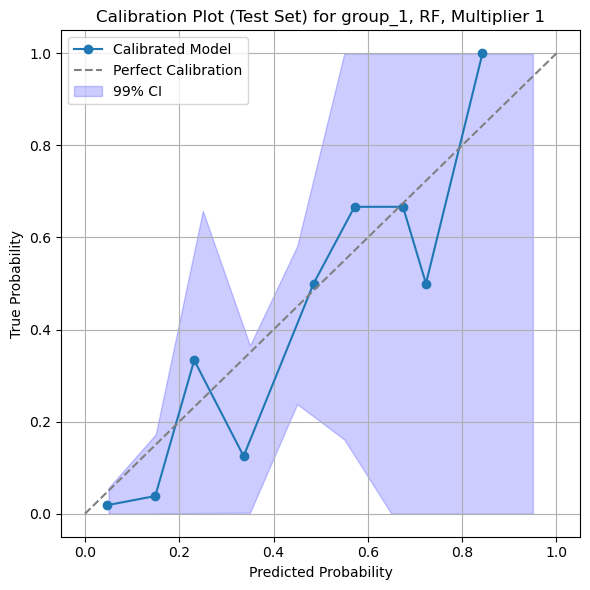

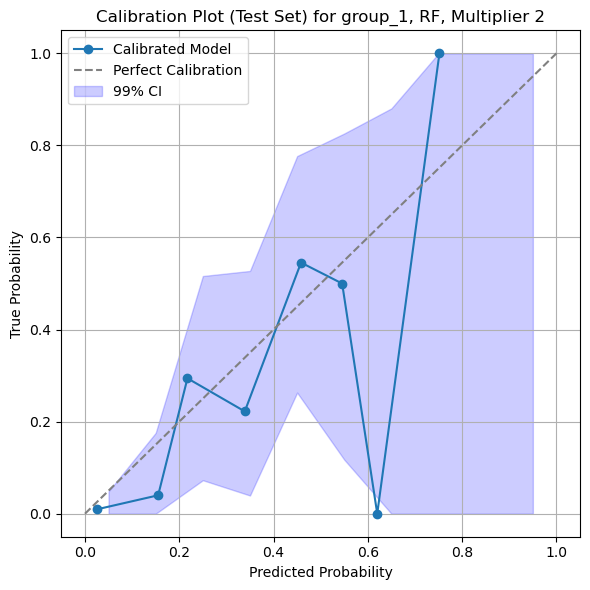

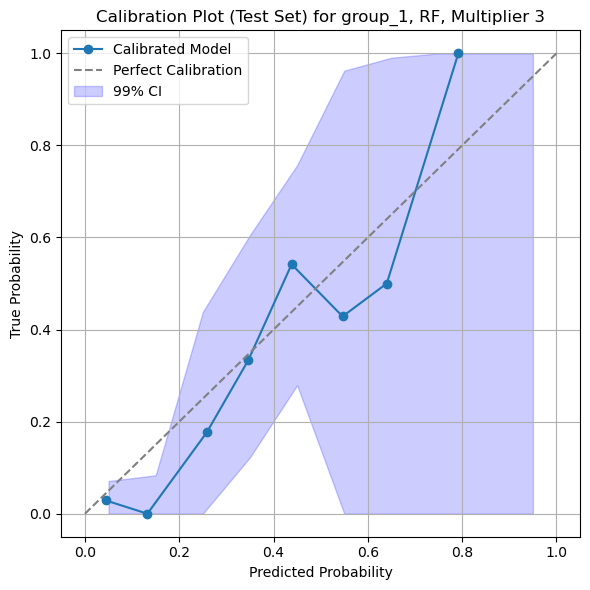

Using CTGAN for group_1


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-01.77) | Discrim. (-00.13): 100%|█████████████████████████████████████████████| 100/100 [00:36<00:00,  2.74it/s]


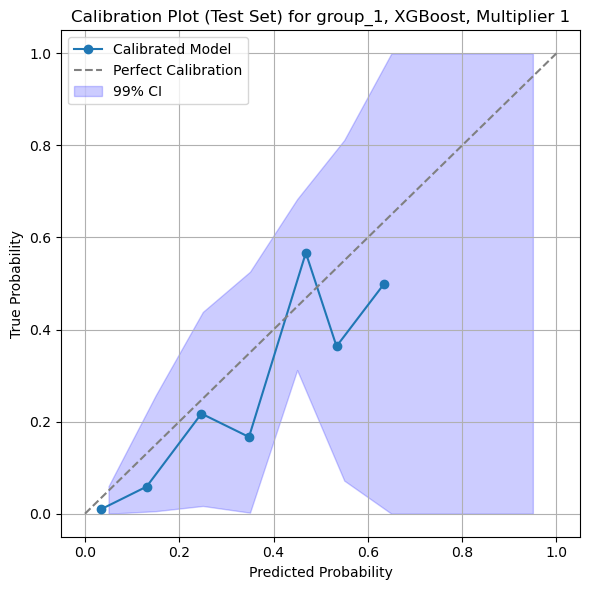

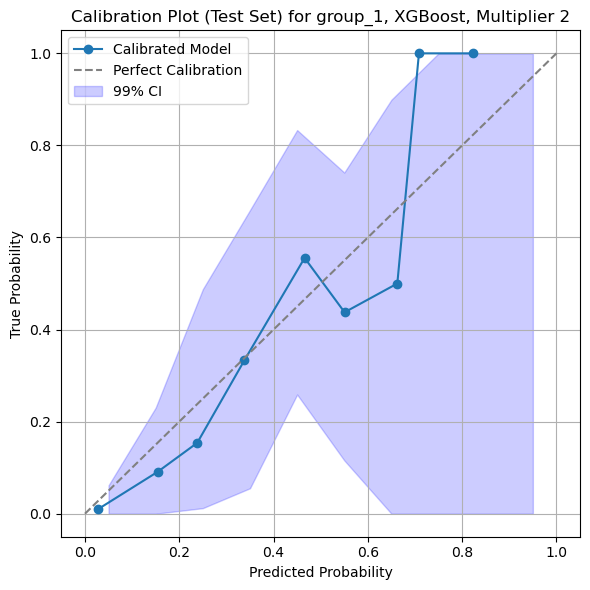

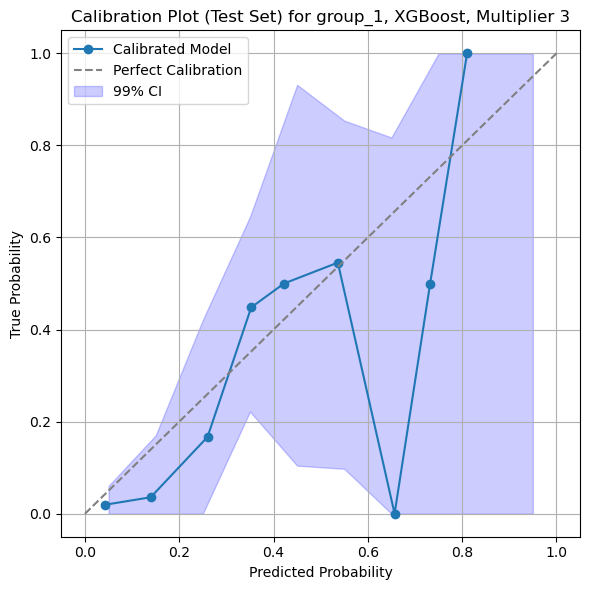

Using CTGAN for group_3


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-01.55) | Discrim. (-00.25): 100%|█████████████████████████████████████████████| 100/100 [00:43<00:00,  2.31it/s]


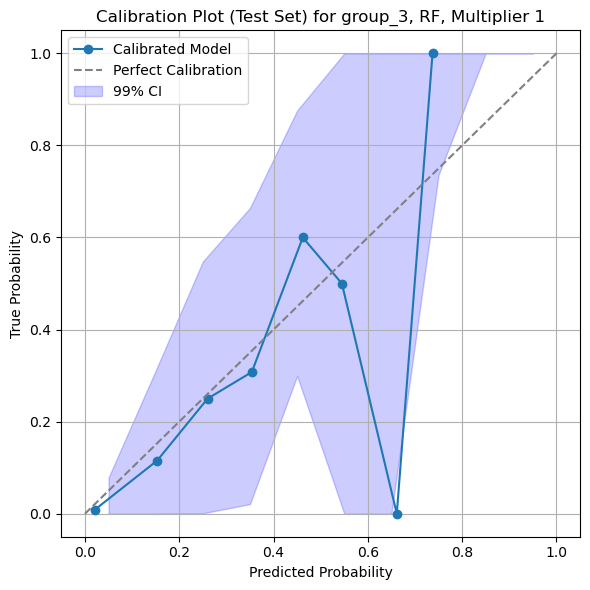

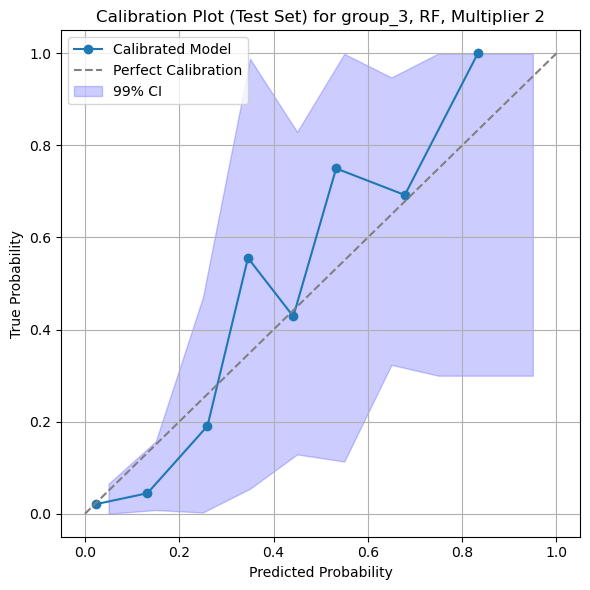

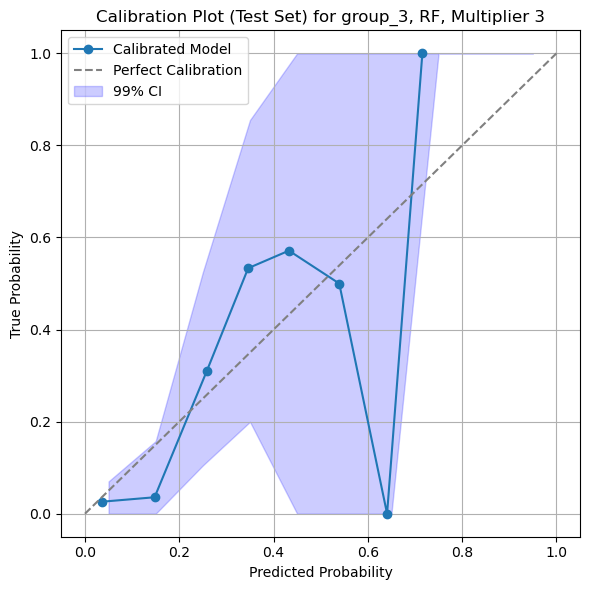

Using CTGAN for group_3


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-01.55) | Discrim. (-00.25): 100%|█████████████████████████████████████████████| 100/100 [00:43<00:00,  2.31it/s]


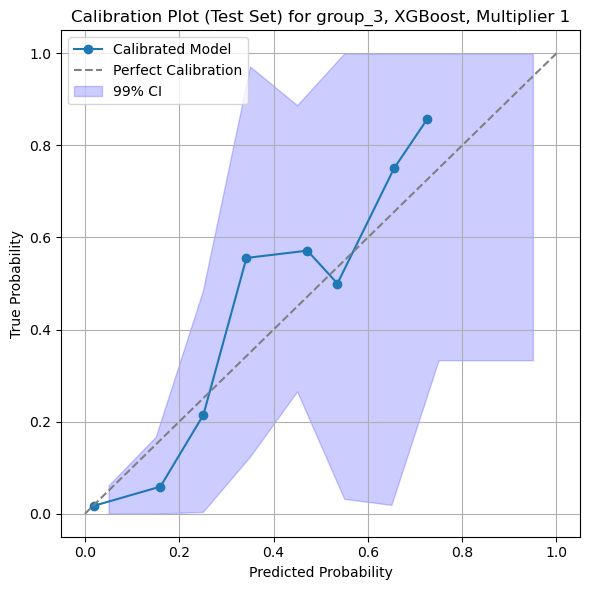

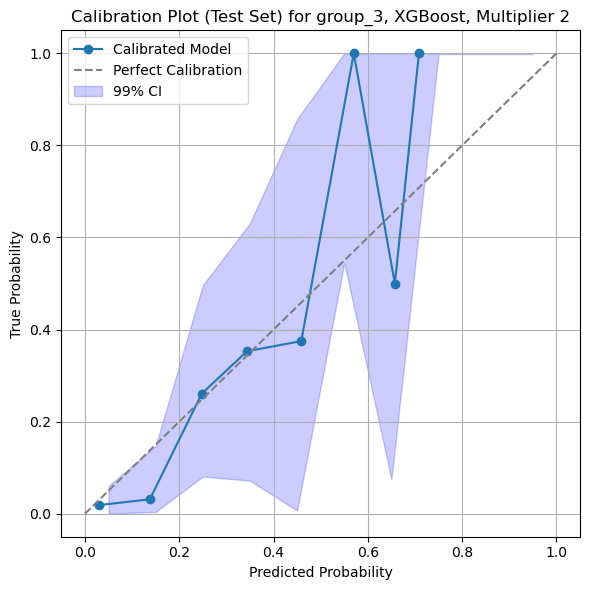

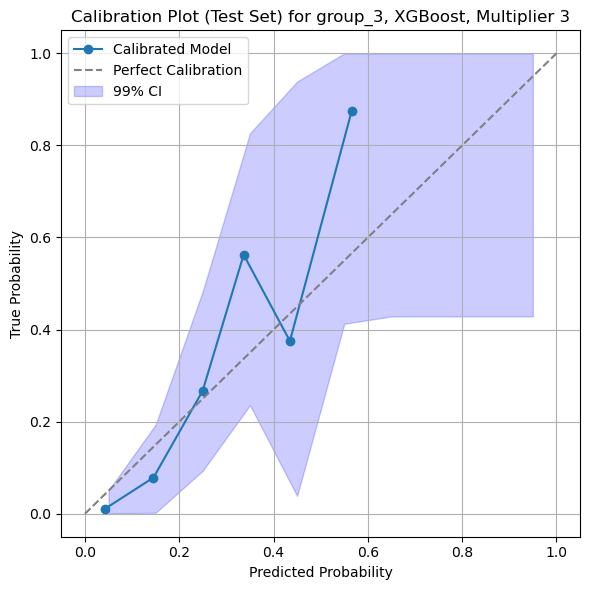

In [17]:
results_rf_group_1 = generate_synthetic_and_run_model(
    group_columns=group_1,
    df=df_Data,
    group_name="group_1",
    method="RF"
)

results_xgb_group_1 = generate_synthetic_and_run_model(
    group_columns=group_1,
    df=df_Data,
    group_name="group_1",
    method="XGBoost"
)


results_rf_group_3 = generate_synthetic_and_run_model(
    group_columns=group_3,
    df=df_Data,
    group_name="group_3",
    method="RF"
)

results_xgb_group_3 = generate_synthetic_and_run_model(
    group_columns=group_3,
    df=df_Data,
    group_name="group_3",
    method="XGBoost"
)

In [18]:
all_results = [results_rf_group_1, results_xgb_group_1, results_rf_group_3, results_xgb_group_3]

In [19]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train AUC": round(res["train_auc"], 3),
            "CV AUC": round(res["cv_auc"], 3),
            "Test AUC": round(res["test_auc"], 3),
            "AUC CI Lower": round(res["ci_auc"][0], 3),
            "AUC CI Upper": round(res["ci_auc"][1], 3),
        })

# Convert to DataFrame and display
summary_df_group_1_3_auc = pd.DataFrame(summary_data)
print(summary_df_group_1_3_auc.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train AUC |   CV AUC |   Test AUC |   AUC CI Lower |   AUC CI Upper |
|:--------|:---------|-------------:|------------:|---------:|-----------:|---------------:|---------------:|
| group_1 | RF       |            1 |       0.89  |    0.821 |      0.877 |          0.809 |          0.936 |
| group_1 | RF       |            2 |       0.859 |    0.786 |      0.873 |          0.808 |          0.931 |
| group_1 | RF       |            3 |       0.854 |    0.793 |      0.866 |          0.797 |          0.928 |
| group_1 | XGBoost  |            1 |       0.915 |    0.811 |      0.87  |          0.801 |          0.928 |
| group_1 | XGBoost  |            2 |       0.893 |    0.782 |      0.882 |          0.823 |          0.933 |
| group_1 | XGBoost  |            3 |       0.878 |    0.789 |      0.874 |          0.814 |          0.93  |
| group_3 | RF       |            1 |       0.907 |    0.825 |      0.91  |          0.858 |          0.954 |
| group_3 

In [20]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train Recall": round(res["train_recall"], 3),
            "CV Recall": round(res["cv_recall"], 3),
            "Test Recall": round(res["test_recall"], 3),
            "Recall CI Lower": round(res["ci_recall"][0], 3),
            "Recall CI Upper": round(res["ci_recall"][1], 3),
        })

# Convert to DataFrame and display
summary_df_group_1_3_recall = pd.DataFrame(summary_data)
print(summary_df_group_1_3_recall.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train Recall |   CV Recall |   Test Recall |   Recall CI Lower |   Recall CI Upper |
|:--------|:---------|-------------:|---------------:|------------:|--------------:|------------------:|------------------:|
| group_1 | RF       |            1 |          0.871 |       0.721 |         0.812 |             0.667 |             0.935 |
| group_1 | RF       |            2 |          0.873 |       0.668 |         0.938 |             0.839 |             1     |
| group_1 | RF       |            3 |          0.795 |       0.681 |         0.812 |             0.659 |             0.938 |
| group_1 | XGBoost  |            1 |          0.965 |       0.717 |         0.906 |             0.792 |             1     |
| group_1 | XGBoost  |            2 |          0.835 |       0.688 |         0.812 |             0.658 |             0.939 |
| group_1 | XGBoost  |            3 |          0.849 |       0.688 |         0.844 |             0.7   |             0.963 |


In [21]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train Specificity": round(res["train_specificity"], 3),
            "CV Specificity": round(res["cv_specificity"], 3),
            "Test Specificity": round(res["test_specificity"], 3),
            "Specificity CI Lower": round(res["ci_specificity"][0], 3),
            "Specificity CI Upper": round(res["ci_specificity"][1], 3),
        })

# Convert to DataFrame and display
summary_df_group_1_3_spec = pd.DataFrame(summary_data)
print(summary_df_group_1_3_spec.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train Specificity |   CV Specificity |   Test Specificity |   Specificity CI Lower |   Specificity CI Upper |
|:--------|:---------|-------------:|--------------------:|-----------------:|-------------------:|-----------------------:|-----------------------:|
| group_1 | RF       |            1 |               0.738 |            0.779 |              0.785 |                  0.719 |                  0.847 |
| group_1 | RF       |            2 |               0.656 |            0.752 |              0.738 |                  0.671 |                  0.805 |
| group_1 | RF       |            3 |               0.745 |            0.757 |              0.773 |                  0.708 |                  0.834 |
| group_1 | XGBoost  |            1 |               0.709 |            0.784 |              0.727 |                  0.657 |                  0.79  |
| group_1 | XGBoost  |            2 |               0.788 |            0.741 |              0.831 | 

In [22]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train F1": round(res["train_f1"], 3),
            "CV F1": round(res["cv_f1"], 3),
            "Test F1": round(res["test_f1"], 3),
            "F1 CI Lower": round(res["ci_f1"][0], 3),
            "F1 CI Upper": round(res["ci_f1"][1], 3),
        })

# Convert to DataFrame and display
summary_df_group_1_3_f1 = pd.DataFrame(summary_data)
print(summary_df_group_1_3_f1.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train F1 |   CV F1 |   Test F1 |   F1 CI Lower |   F1 CI Upper |
|:--------|:---------|-------------:|-----------:|--------:|----------:|--------------:|--------------:|
| group_1 | RF       |            1 |      0.613 |   0.567 |     0.547 |         0.414 |         0.667 |
| group_1 | RF       |            2 |      0.594 |   0.548 |     0.561 |         0.435 |         0.673 |
| group_1 | RF       |            3 |      0.613 |   0.558 |     0.536 |         0.4   |         0.654 |
| group_1 | XGBoost  |            1 |      0.634 |   0.569 |     0.537 |         0.409 |         0.649 |
| group_1 | XGBoost  |            2 |      0.671 |   0.552 |     0.598 |         0.453 |         0.716 |
| group_1 | XGBoost  |            3 |      0.637 |   0.555 |     0.551 |         0.41  |         0.667 |
| group_3 | RF       |            1 |      0.579 |   0.515 |     0.577 |         0.442 |         0.692 |
| group_3 | RF       |            2 |      0.595 |   0.

In [23]:
# Create the summary list
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
    "Group": res["group"],
    "Method": res["method"],
    "Multiplier": res["sample_multiplier"],
    "Best Params": str(res["best_params"])
        
    })
# Convert to DataFrame
summary_df_group_1_3_bestparams = pd.DataFrame(summary_data)
print(summary_df_group_1_3_bestparams.to_markdown(index=False))   

| Group   | Method   |   Multiplier | Best Params                                                                                                                                                |
|:--------|:---------|-------------:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------|
| group_1 | RF       |            1 | {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_samples': 0.7, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}       |
| group_1 | RF       |            2 | {'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_samples': 0.5, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}       |
| group_1 | RF       |            3 | {'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_samples': 0.5, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}       |
| group_1 | XGBoost  |   

In [24]:
# CTGAN + RF and CTGAN + XGBoost for group_4

def compute_confidence_interval(metric_fn, y_true, y_score, threshold=None, n_bootstraps=1000, ci=0.95):
    stats = []
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    rng = np.random.RandomState(100)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue

        if threshold is not None:
            y_pred = (y_score[indices] >= threshold).astype(int)
            value = metric_fn(y_true[indices], y_pred)
        else:
            value = metric_fn(y_true[indices], y_score[indices])

        stats.append(value)

    lower = np.percentile(stats, (1 - ci) / 2 * 100)
    upper = np.percentile(stats, (1 + ci) / 2 * 100)
    return lower, upper

def generate_synthetic_and_run_model(group_columns, df, group_name,
                                     target_col="convert_Within_3Years",
                                     method="RF",  # "RF" or "XGBoost"
                                     test_size=0.3,
                                     random_state=100,
                                     sample_multiplier=[1, 2, 3]):
    # Only allow group_2
    if group_name not in ["group_4"]:
        raise ValueError(f"CTGAN augmentation is only supported for 'group_4'. Got: {group_name}")

    real_data_group = pd.concat([df[group_columns], df[target_col]], axis=1)

    train_data, test_data = train_test_split(
        real_data_group,
        test_size=test_size,
        random_state=random_state,
        stratify=real_data_group[target_col]
    )
    
    
    np.random.seed(42)
    torch.manual_seed(42)

    
    print(f"Using CTGAN for {group_name}")


    synthesizer = CTGAN(
        embedding_dim=64,
        generator_dim=[128, 64],
        discriminator_dim=[256, 128],
        batch_size=64,
        epochs=50,
        pac=1,
        cuda=True,
        verbose=True
    )
    
    synthesizer.fit(train_data)

    results = []

    for mult in sample_multiplier:
        synthetic_data = synthesizer.sample(len(train_data) * mult)
        save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\synthetic_data\CTGAN\group_4"        
        filename = f"synthetic_{group_name}_CTGAN_{mult}x.csv"
        save_path = os.path.join(save_dir, filename)
        synthetic_data.to_csv(save_path, index=False)

        augmented_train = pd.concat([train_data, synthetic_data], ignore_index=True)
        
        X_train_aug = augmented_train[group_columns]
        y_train_aug = augmented_train[target_col]
        X_test = test_data[group_columns]
        y_test = test_data[target_col]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

        if method.upper() == "RF":
            model = RandomForestClassifier(random_state=100, class_weight='balanced')
            param_dist = {
                'n_estimators': [150, 200],
                'max_depth': [4, 5],
                'min_samples_split': [10, 15, 20],
                'min_samples_leaf': [6, 8, 10],
                'max_features': ['log2'],
                'bootstrap': [True],
                'max_samples': [0.5, 0.7, 0.9]
            }
        elif method.upper() == "XGBOOST":
            neg_count = (y_train_aug == 0).sum()
            pos_count = (y_train_aug == 1).sum()
            scale_pos_weight = neg_count / pos_count
            model = xgb.XGBClassifier(eval_metric='logloss', random_state=100, scale_pos_weight=scale_pos_weight)
            param_dist = {
                'n_estimators': [50, 100],
                'max_depth': [2],
                'learning_rate': [0.005, 0.01],
                'subsample': [0.5, 0.6],
                'colsample_bytree': [0.5, 0.7],
                'gamma': [0.5, 1.0],
                'reg_alpha': [0.5, 1.0],
                'reg_lambda': [2.0, 5.0]
            }
        else:
            raise ValueError(f"Invalid method '{method}'. Choose 'RF' or 'XGBoost'.")

        def specificity_score(y_true, y_pred):
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            return tn / (tn + fp) if (tn + fp) > 0 else 0

        scoring = {
            'roc_auc': 'roc_auc',
            'f1': make_scorer(f1_score),
            'recall': make_scorer(recall_score),
            'specificity': make_scorer(specificity_score)
        }
        search = RandomizedSearchCV(
            model,
            param_distributions=param_dist,
            cv=cv,
            scoring=scoring,
            refit='roc_auc',
            random_state=100
        )

        search.fit(X_train_aug, y_train_aug)
        best_params = search.best_params_

        # Calibration step
        uncalibrated_model = xgb.XGBClassifier(**best_params, random_state=100, scale_pos_weight=scale_pos_weight) if method.upper() == "XGBOOST" else RandomForestClassifier(**best_params, random_state=100, class_weight='balanced')
        calibrated_model = CalibratedClassifierCV(uncalibrated_model, method='isotonic', cv=3)
        calibrated_model.fit(X_train_aug, y_train_aug)

        y_train_proba = calibrated_model.predict_proba(X_train_aug)[:, 1]
        y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

        # --- Youden threshold ---
        youden_thresholds = []
        for train_idx, val_idx in cv.split(X_train_aug, y_train_aug):
          X_tr, X_val = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
          y_tr, y_val = y_train_aug.iloc[train_idx], y_train_aug.iloc[val_idx]

          if method.upper() == "XGBOOST":
            model_cv = xgb.XGBClassifier(**best_params, random_state=100, scale_pos_weight=scale_pos_weight)
          else:
            model_cv = RandomForestClassifier(**best_params, random_state=100, class_weight='balanced')
          model_cv_calibrated = CalibratedClassifierCV(model_cv, method='isotonic', cv=3)
          model_cv_calibrated.fit(X_tr, y_tr)

          y_val_proba = model_cv_calibrated.predict_proba(X_val)[:, 1]
          fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
          youden = tpr - fpr
          best_thresh = thresholds[np.argmax(youden)]
          youden_thresholds.append(best_thresh)

        optimal_threshold = np.mean(youden_thresholds)

        y_train_pred = (y_train_proba >= optimal_threshold).astype(int)
        y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

        # Evaluation metrics
        test_f1 = f1_score(y_test, y_test_pred)
        test_recall = recall_score(y_test, y_test_pred)
        tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
        test_specificity = tn_test / (tn_test + fp_test)
        test_auc = roc_auc_score(y_test, y_test_proba)

        train_f1 = f1_score(y_train_aug, y_train_pred)
        train_recall = recall_score(y_train_aug, y_train_pred)
        tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train_aug, y_train_pred).ravel()
        train_specificity = tn_train / (tn_train + fp_train)
        train_auc = roc_auc_score(y_train_aug, y_train_proba)

        cv_results = search.cv_results_
        best_idx = search.best_index_
        cv_auc = cv_results['mean_test_roc_auc'][best_idx]
        cv_f1 = cv_results['mean_test_f1'][best_idx]
        cv_recall = cv_results['mean_test_recall'][best_idx]
        cv_specificity = cv_results['mean_test_specificity'][best_idx]

        ci_auc = compute_confidence_interval(roc_auc_score, y_test, y_test_proba, threshold=None)
        ci_f1 = compute_confidence_interval(f1_score, y_test, y_test_proba, threshold=optimal_threshold)
        ci_recall = compute_confidence_interval(recall_score, y_test, y_test_proba, threshold=optimal_threshold)
        ci_spec = compute_confidence_interval(specificity_score, y_test, y_test_proba, threshold=optimal_threshold)

        n_bins = 10
        n_bootstrap = 1000
        ci = 99
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
        bootstrap_curves = []
        rng = np.random.RandomState(100)
        
        for _ in range(n_bootstrap):
            indices = rng.randint(0, len(y_test), len(y_test))
            y_bs = y_test.iloc[indices]
            p_bs = y_test_proba[indices]
            if len(np.unique(y_bs)) < 2:
                continue
            for _ in range(n_bootstrap):
                y_bs, p_bs = resample(y_test, y_test_proba, random_state=None)
            try:
                pt_bs, pp_bs = calibration_curve(y_bs, p_bs, n_bins=n_bins, strategy='uniform')
                interp = np.interp(bin_centers, pp_bs, pt_bs)
                bootstrap_curves.append(interp)
            except:
                continue

        bootstrap_array = np.array(bootstrap_curves)
        lower_bound = np.percentile(bootstrap_array, (100 - ci) / 2, axis=0)
        upper_bound = np.percentile(bootstrap_array, 100 - (100 - ci) / 2, axis=0)

        prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=n_bins, strategy='uniform')
        plt.figure(figsize=(6, 6))
        plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
        plt.fill_between(bin_centers, lower_bound, upper_bound, color='blue', alpha=0.2, label='99% CI')
        plt.xlabel('Predicted Probability')
        plt.ylabel('True Probability')
        plt.title(f'Calibration Plot (Test Set) for {group_name}, {method}, Multiplier {mult}')
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.savefig(os.path.join(fig_save_dir, f"calibration_{group_name}_{method}_Multiplier_{mult}.pdf"), dpi=600,bbox_inches="tight")
        plt.show()
        plt.close()


        results.append({
            'group': group_name,
            'method': method,
            'sample_multiplier': mult,
            'train_auc': train_auc,
            'cv_auc': cv_auc,
            'test_auc': test_auc,
            'train_f1': train_f1,
            'cv_f1': cv_f1,
            'test_f1': test_f1,
            'train_recall': train_recall,
            'cv_recall': cv_recall,
            'test_recall': test_recall,
            'train_specificity': train_specificity,
            'cv_specificity': cv_specificity,
            'test_specificity': test_specificity,
            'ci_auc': ci_auc,
            'ci_f1': ci_f1,
            'ci_recall': ci_recall,
            'ci_specificity': ci_spec,
            'best_params': search.best_params_
        })

    return results


Using CTGAN for group_4


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-00.52) | Discrim. (-00.16): 100%|███████████████████████████████████████████████| 50/50 [00:11<00:00,  4.52it/s]


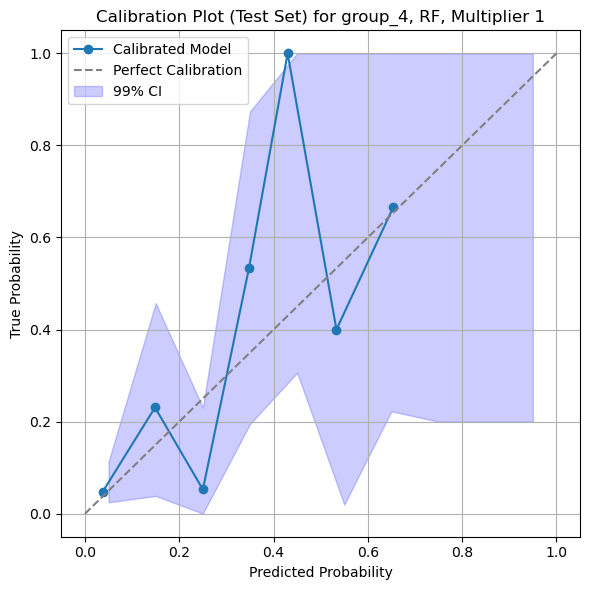

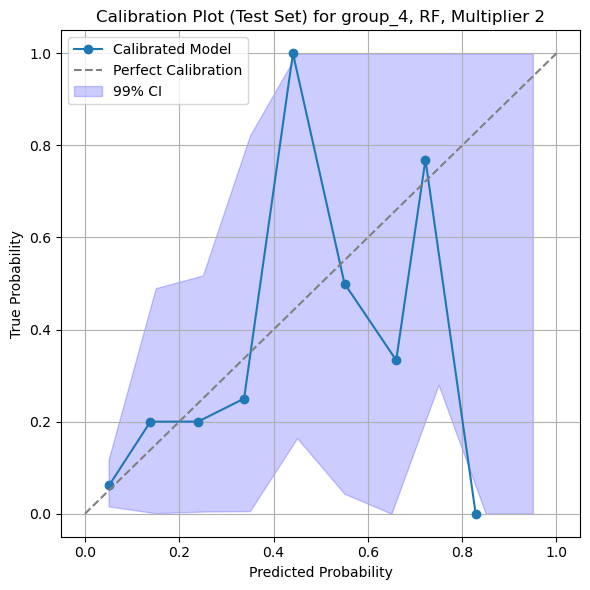

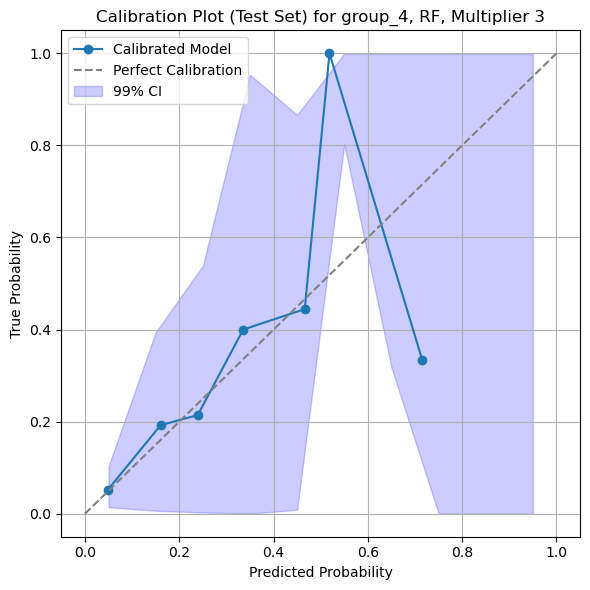

Using CTGAN for group_4


C:\Users\lotus\anaconda3\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-00.52) | Discrim. (-00.16): 100%|███████████████████████████████████████████████| 50/50 [00:11<00:00,  4.25it/s]


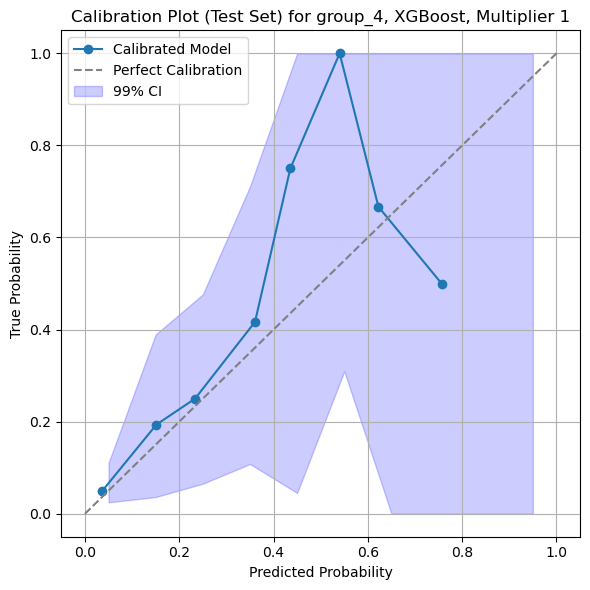

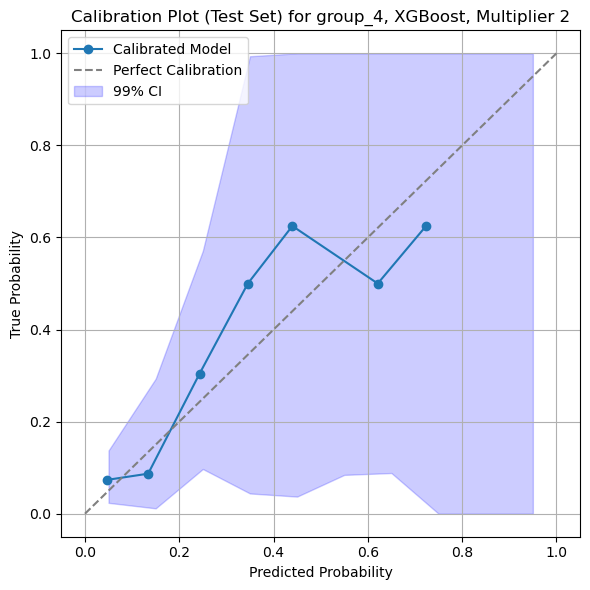

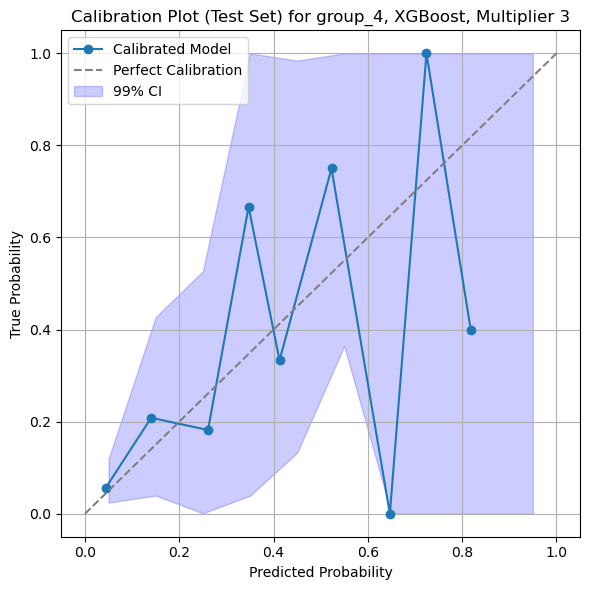

In [25]:
results_rf_group_4 = generate_synthetic_and_run_model(
    group_columns=group_4,
    df=df_Data,
    group_name="group_4",
    method="RF"
)

results_xgb_group_4 = generate_synthetic_and_run_model(
    group_columns=group_4,
    df=df_Data,
    group_name="group_4",
    method="XGBoost"
)

In [26]:
all_results = [results_rf_group_4, results_xgb_group_4]

In [27]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train AUC": round(res["train_auc"], 3),
            "CV AUC": round(res["cv_auc"], 3),
            "Test AUC": round(res["test_auc"], 3),
            "AUC CI Lower": round(res["ci_auc"][0], 3),
            "AUC CI Upper": round(res["ci_auc"][1], 3)
        })

# Convert to DataFrame and display
summary_df_group_4_auc = pd.DataFrame(summary_data)
print(summary_df_group_4_auc.to_markdown(index=False))


| Group   | Method   |   Multiplier |   Train AUC |   CV AUC |   Test AUC |   AUC CI Lower |   AUC CI Upper |
|:--------|:---------|-------------:|------------:|---------:|-----------:|---------------:|---------------:|
| group_4 | RF       |            1 |       0.943 |    0.82  |      0.842 |          0.764 |          0.91  |
| group_4 | RF       |            2 |       0.929 |    0.786 |      0.846 |          0.772 |          0.912 |
| group_4 | RF       |            3 |       0.952 |    0.783 |      0.837 |          0.755 |          0.908 |
| group_4 | XGBoost  |            1 |       0.887 |    0.806 |      0.84  |          0.771 |          0.904 |
| group_4 | XGBoost  |            2 |       0.848 |    0.761 |      0.823 |          0.743 |          0.893 |
| group_4 | XGBoost  |            3 |       0.859 |    0.77  |      0.831 |          0.741 |          0.907 |


In [28]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],


            "Train Recall": round(res["train_recall"], 3),
            "CV Recall": round(res["cv_recall"], 3),
            "Test Recall": round(res["test_recall"], 3),
            "Recall CI Lower": round(res["ci_recall"][0], 3),
            "Recall CI Upper": round(res["ci_recall"][1], 3)
        })

# Convert to DataFrame and display
summary_df_group_4_recall = pd.DataFrame(summary_data)
print(summary_df_group_4_recall.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train Recall |   CV Recall |   Test Recall |   Recall CI Lower |   Recall CI Upper |
|:--------|:---------|-------------:|---------------:|------------:|--------------:|------------------:|------------------:|
| group_4 | RF       |            1 |          0.894 |       0.518 |         0.781 |             0.625 |             0.921 |
| group_4 | RF       |            2 |          0.891 |       0.435 |         0.906 |             0.786 |             1     |
| group_4 | RF       |            3 |          0.952 |       0.461 |         0.906 |             0.786 |             1     |
| group_4 | XGBoost  |            1 |          0.8   |       0.659 |         0.812 |             0.674 |             0.943 |
| group_4 | XGBoost  |            2 |          0.663 |       0.584 |         0.688 |             0.514 |             0.844 |
| group_4 | XGBoost  |            3 |          0.74  |       0.586 |         0.875 |             0.75  |             0.974 |


In [29]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train Specificity": round(res["train_specificity"], 3),
            "CV Specificity": round(res["cv_specificity"], 3),
            "Test Specificity": round(res["test_specificity"], 3),
            "Specificity CI Lower": round(res["ci_specificity"][0], 3),
            "Specificity CI Upper": round(res["ci_specificity"][1], 3)
        })

# Convert to DataFrame and display
summary_df_group_4_spec = pd.DataFrame(summary_data)
print(summary_df_group_4_spec.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train Specificity |   CV Specificity |   Test Specificity |   Specificity CI Lower |   Specificity CI Upper |
|:--------|:---------|-------------:|--------------------:|-----------------:|-------------------:|-----------------------:|-----------------------:|
| group_4 | RF       |            1 |               0.852 |            0.916 |              0.738 |                  0.67  |                  0.808 |
| group_4 | RF       |            2 |               0.812 |            0.932 |              0.57  |                  0.5   |                  0.646 |
| group_4 | RF       |            3 |               0.831 |            0.936 |              0.517 |                  0.442 |                  0.588 |
| group_4 | XGBoost  |            1 |               0.825 |            0.807 |              0.721 |                  0.652 |                  0.788 |
| group_4 | XGBoost  |            2 |               0.864 |            0.813 |              0.733 | 

In [30]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],

            "Train F1": round(res["train_f1"], 3),
            "CV F1": round(res["cv_f1"], 3),
            "Test F1": round(res["test_f1"], 3),
            "F1 CI Lower": round(res["ci_f1"][0], 3),
            "F1 CI Upper": round(res["ci_f1"][1], 3),
        })

# Convert to DataFrame and display
summary_df_group_4_f1 = pd.DataFrame(summary_data)
print(summary_df_group_4_f1.to_markdown(index=False))

| Group   | Method   |   Multiplier |   Train F1 |   CV F1 |   Test F1 |   F1 CI Lower |   F1 CI Upper |
|:--------|:---------|-------------:|-----------:|--------:|----------:|--------------:|--------------:|
| group_4 | RF       |            1 |      0.528 |   0.437 |     0.49  |         0.361 |         0.612 |
| group_4 | RF       |            2 |      0.41  |   0.376 |     0.43  |         0.321 |         0.535 |
| group_4 | RF       |            3 |      0.391 |   0.363 |     0.403 |         0.29  |         0.506 |
| group_4 | XGBoost  |            1 |      0.447 |   0.363 |     0.491 |         0.366 |         0.612 |
| group_4 | XGBoost  |            2 |      0.386 |   0.292 |     0.44  |         0.311 |         0.567 |
| group_4 | XGBoost  |            3 |      0.278 |   0.274 |     0.415 |         0.301 |         0.522 |


In [31]:
# Flatten results
summary_data = []
for res_list in all_results:
    for res in res_list:
        summary_data.append({
            "Group": res["group"],
            "Method": res["method"],
            "Multiplier": res["sample_multiplier"],
            "Best Params": str(res["best_params"])
        })

# Convert to DataFrame and display
summary_df_group_4_bestparams = pd.DataFrame(summary_data)
print(summary_df_group_4_bestparams.to_markdown(index=False))

| Group   | Method   |   Multiplier | Best Params                                                                                                                                                 |
|:--------|:---------|-------------:|:------------------------------------------------------------------------------------------------------------------------------------------------------------|
| group_4 | RF       |            1 | {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_samples': 0.7, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}        |
| group_4 | RF       |            2 | {'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_samples': 0.5, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}       |
| group_4 | RF       |            3 | {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_samples': 0.7, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}        |
| group_4 | XGBoost 